In [1]:
!pwd

/Users/linghuang/Git/Deep-Learning/AI-Modeling/wk02


In [6]:
from huggingface_hub import snapshot_download
import os

# 1. Download the neuml/glove-6B model files from Hugging Face
model_repo = "neuml/glove-6B"

# This will download all embeddings (50d, 100d, 200d, 300d)
local_dir = snapshot_download(repo_id=model_repo)
print("Snapshot dir:", local_dir)

Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 117597.31it/s]

Snapshot dir: /Users/linghuang/.cache/huggingface/hub/models--neuml--glove-6B/snapshots/a5d0cac7bc39cdee78924150e199990dba7f650e


In [9]:
from staticvectors import StaticVectors

model = StaticVectors("neuml/glove-6B/model.sqlite")

In [10]:
import numpy as np

vecs = model.embeddings(["girl", "woman"])

vecs

array([[-0.08225909, -0.01461916, -0.09930599, -0.02449884, -0.04706354,
         0.0005833 , -0.01478612, -0.00804671, -0.05987543, -0.09231981,
         0.02826815,  0.01937101,  0.01693396,  0.04311786, -0.00474009,
        -0.04093613, -0.02850334, -0.06175698, -0.01225144, -0.05475222,
        -0.0428548 ,  0.16571888, -0.05833891,  0.00654706, -0.02655835,
        -0.06109782,  0.03148659, -0.02214382, -0.0038971 ,  0.05505859,
        -0.05228887,  0.00364055, -0.01535229,  0.01539081, -0.09639703,
         0.10374374, -0.06482223,  0.05658117,  0.02418629,  0.04804301,
         0.07132566, -0.12097944,  0.02895826,  0.00611613,  0.00204804,
        -0.0125742 ,  0.07712969, -0.06769717, -0.00677389, -0.00221469,
         0.02501721, -0.05722795, -0.01771536,  0.07062317, -0.06915321,
        -0.06584347, -0.01863138, -0.02294688,  0.06441838, -0.10219023,
         0.03385091,  0.04349695,  0.05801863,  0.00343259, -0.03056283,
        -0.07607596,  0.0268384 , -0.05902131, -0.0

In [11]:
# a*b/|a||b|

cos_sim = np.dot(vecs[0], vecs[1])/(np.linalg.norm(vecs[0])*np.linalg.norm(vecs[1]))

cos_sim

np.float32(0.729642)

In [12]:
vecs2 = model.embeddings(["apple", "woman"])
cos_sim = np.dot(vecs2[0], vecs2[1])/(np.linalg.norm(vecs2[0])*np.linalg.norm(vecs2[1]))
cos_sim

np.float32(0.09335046)

In [13]:
# |a-b|

dis1 = np.linalg.norm(vecs[0]-vecs[1])
dis1

np.float32(0.73533404)

In [14]:
dis2 = np.linalg.norm(vecs2[0]-vecs2[1])
dis2

np.float32(1.3465879)

In [15]:
from sklearn.manifold import TSNE

word_list =  ["boy", "girl", "woman", "man", "king", "queen", "water",
             "apple", "banana", "orange", "pear", "strawberry", "flower"
             ]

vecs = model.embeddings(word_list)

tsne = TSNE(n_components=2, random_state=42, perplexity=10)

vecs2_2d = tsne.fit_transform(vecs)

vecs2_2d

array([[  -6.3622074,  -33.76569  ],
       [ -39.741302 ,  -65.263954 ],
       [   3.7984424,  -95.48724  ],
       [  39.256622 ,  -62.251766 ],
       [  79.78831  ,   28.461994 ],
       [  40.412174 ,    8.957612 ],
       [  93.5787   ,  -44.680424 ],
       [ -18.89328  ,   44.784164 ],
       [ -79.28692  ,   64.515594 ],
       [  16.98909  ,   82.89829  ],
       [ -56.907917 ,   18.23013  ],
       [ -40.765453 ,   95.59452  ],
       [-102.17483  ,    0.6191495]], dtype=float32)

/Users/linghuang/miniconda3/envs/llm/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35789 (\N{CJK UNIFIED IDEOGRAPH-8BCD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/linghuang/miniconda3/envs/llm/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/linghuang/miniconda3/envs/llm/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/linghuang/miniconda3/envs/llm/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21487 (\N{CJK UNIFIED IDEOGRAPH-53EF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/linghuang/miniconda3/envs/llm/lib/python3.11/site-packages/IPytho

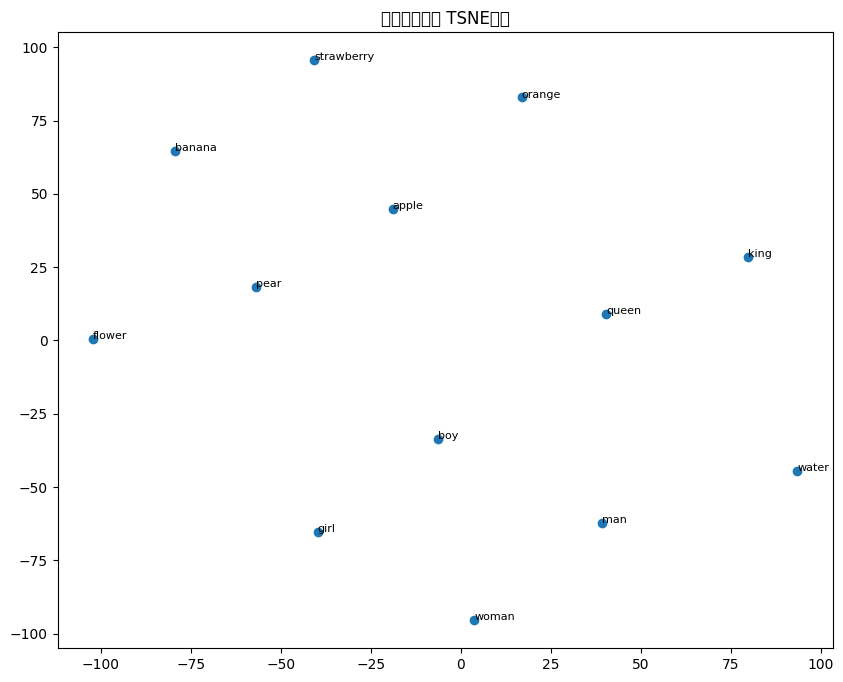

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

plt.scatter(vecs2_2d[:,0], vecs2_2d[:,1])

for i,word in enumerate(word_list):
    plt.annotate(word, (vecs2_2d[i,0], vecs2_2d[i,1]), fontsize=8)

plt.title("词向量可视化 TSNE降维")
plt.show()